In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# nashville = pd.read_csv("data/nashville_daily.csv")
# summers = nashville.loc[nashville["month"].between(6, 8)].copy()
# summers["period"] = np.select(
#     [summers["year"] <= 2005, summers["year"] >= 2012],
#     ["1991-2005", "2012-2026"],
#     default=""
# )
# summers = summers[summers["period"] != ""]
# early = summers.loc[summers["period"] == "1991-2005"].copy()
# late = summers.loc[summers["period"] == "2012-2026"].copy()

In [17]:
nashville = pd.read_csv("data/nashville_daily.csv")
summers = nashville.loc[nashville["month"].between(6, 8)].copy()

summers.head()

,date,year,month,tmax_f,tmin_f,tmax_normal_f,tmax_anomaly_f,precip_in
151,1991-06-01,1991,6,90,72,82.4,7.6,0.00
152,1991-06-02,1991,6,90,71,82.7,7.3,0.00
153,1991-06-03,1991,6,94,73,83.0,11.0,0.00
154,1991-06-04,1991,6,92,71,83.2,8.8,0.04
155,1991-06-05,1991,6,83,65,83.5,-0.5,0.00


In [18]:
print(summers.dtypes)

date                  str
year                int64
month               int64
tmax_f              int64
tmin_f              int64
tmax_normal_f     float64
tmax_anomaly_f    float64
precip_in         float64
dtype: object


In [19]:
summers["period"] = np.select(
    [summers["year"] <= 2005, summers["year"] >= 2012],
    ["1991-2005", "2012-2026"],
    default=""
)
summers = summers[summers["period"] != ""]
summers

,date,year,month,tmax_f,tmin_f,tmax_normal_f,tmax_anomaly_f,precip_in,period
151,1991-06-01,1991,6,90,72,82.4,7.6,0.00,1991-2005
152,1991-06-02,1991,6,90,71,82.7,7.3,0.00,1991-2005
153,1991-06-03,1991,6,94,73,83.0,11.0,0.00,1991-2005
154,1991-06-04,1991,6,92,71,83.2,8.8,0.04,1991-2005
155,1991-06-05,1991,6,83,65,83.5,-0.5,0.00,1991-2005
...,...,...,...,...,...,...,...,...,...
13022,2026-08-27,2026,8,91,66,88.2,2.8,0.00,2012-2026
13023,2026-08-28,2026,8,92,69,88.0,4.0,0.00,2012-2026
13024,2026-08-29,2026,8,94,67,87.8,6.2,0.00,2012-2026
13025,2026-08-30,2026,8,95,70,87.6,7.4,0.00,2012-2026


In [20]:
early = summers.loc[summers["period"] == "1991-2005"].copy()
early

,date,year,month,tmax_f,tmin_f,tmax_normal_f,tmax_anomaly_f,precip_in,period
151,1991-06-01,1991,6,90,72,82.4,7.6,0.00,1991-2005
152,1991-06-02,1991,6,90,71,82.7,7.3,0.00,1991-2005
153,1991-06-03,1991,6,94,73,83.0,11.0,0.00,1991-2005
154,1991-06-04,1991,6,92,71,83.2,8.8,0.04,1991-2005
155,1991-06-05,1991,6,83,65,83.5,-0.5,0.00,1991-2005
...,...,...,...,...,...,...,...,...,...
5352,2005-08-27,2005,8,84,72,88.2,-4.2,0.00,1991-2005
5353,2005-08-28,2005,8,86,71,88.0,-2.0,0.05,1991-2005
5354,2005-08-29,2005,8,75,70,87.8,-12.8,0.55,1991-2005
5355,2005-08-30,2005,8,77,69,87.6,-10.6,1.97,1991-2005


In [21]:
late = summers.loc[summers["period"] == "2012-2026"].copy()
late

,date,year,month,tmax_f,tmin_f,tmax_normal_f,tmax_anomaly_f,precip_in,period
7822,2012-06-01,2012,6,68,52,82.4,-14.4,0.02,2012-2026
7823,2012-06-02,2012,6,78,48,82.7,-4.7,0.00,2012-2026
7824,2012-06-03,2012,6,88,57,83.0,5.0,0.02,2012-2026
7825,2012-06-04,2012,6,86,65,83.2,2.8,0.03,2012-2026
7826,2012-06-05,2012,6,81,62,83.5,-2.5,0.01,2012-2026
...,...,...,...,...,...,...,...,...,...
13022,2026-08-27,2026,8,91,66,88.2,2.8,0.00,2012-2026
13023,2026-08-28,2026,8,92,69,88.0,4.0,0.00,2012-2026
13024,2026-08-29,2026,8,94,67,87.8,6.2,0.00,2012-2026
13025,2026-08-30,2026,8,95,70,87.6,7.4,0.00,2012-2026


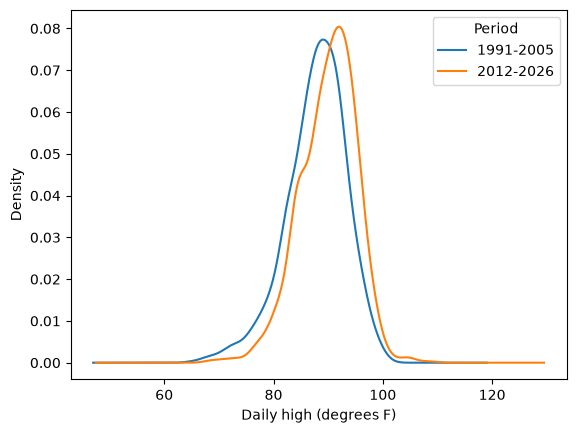

In [22]:
for period, group in summers.groupby("period"):
    group["tmax_f"].plot(kind="density", label=period)
plt.xlabel("Daily high (degrees F)")
plt.ylabel("Density")
plt.legend(title="Period")
plt.show()

In [23]:
early["tmax_f"].median()
late["tmax_f"].median()
early["tmax_f"].quantile([0.1, 0.9])
late["tmax_f"].quantile([0.1, 0.9])

0.1    83.0
0.9    96.0
Name: tmax_f, dtype: float64

In [24]:
early_days_95 = (early["tmax_f"] >= 95).sum() / 15
late_days_95 = (late["tmax_f"] >= 95).sum() / 15
print(early_days_95)
print(late_days_95)

8.2
16.666666666666668
